# Testing results

In [1]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def get_predictions(trainer, tokenized_datasets, dataset):

    predictions = trainer.predict(tokenized_datasets[dataset])

    logits = predictions.predictions
    labels = predictions.label_ids
    predicted_classes = np.argmax(logits, axis=1)

    metrics = compute_metrics((logits, labels))

    print("Evaluation of: ", dataset)
    print(metrics)

    return labels, predicted_classes

def display_cm(labels, predicted_classes):

    class_report = classification_report(labels, predicted_classes)
    print("Classification Report:\n", class_report)

    print("\nConfusion Matrix:")
    cm = confusion_matrix(labels, predicted_classes)

    plt.figure(figsize=(20, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='icefire')
    plt.title(f"Confusion Matrix:")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

In [ ]:
labels, predicted_classes = get_predictions(trainer, tokenized_datasets, "test")
display_cm(labels, predicted_classes)

In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
from transformers import BertForSequenceClassification, Trainer
from collections import defaultdict

def plot_metrics_by_epoch(checkpoint_dir):
    model = BertForSequenceClassification.from_pretrained(checkpoint_dir)
    trainer = Trainer(model=model)

    # Load trainer state
    with open(f"{checkpoint_dir}/trainer_state.json") as f:
        state = json.load(f)

    log_history = state["log_history"]

    # Containers: lists grouped by epoch
    train_loss_by_epoch = defaultdict(list)
    eval_loss_by_epoch = defaultdict(list)
    eval_acc_by_epoch = defaultdict(list)

    for entry in log_history:
        if "epoch" not in entry:
            continue
        epoch = entry["epoch"]

        # Training loss
        if "loss" in entry:
            train_loss_by_epoch[epoch].append(entry["loss"])

        # Validation loss
        if "eval_loss" in entry:
            eval_loss_by_epoch[epoch].append(entry["eval_loss"])

        # Validation accuracy (your metric key!)
        if "eval_Accuracy" in entry:
            eval_acc_by_epoch[epoch].append(entry["eval_Accuracy"])

    # Average values per epoch (HF logs multiple steps per epoch sometimes)
    epochs = sorted(set(list(train_loss_by_epoch.keys()) +
                        list(eval_loss_by_epoch.keys())   +
                        list(eval_acc_by_epoch.keys())))

    train_loss = [np.mean(train_loss_by_epoch[e]) if e in train_loss_by_epoch else None for e in epochs]
    eval_loss  = [np.mean(eval_loss_by_epoch[e])  if e in eval_loss_by_epoch  else None for e in epochs]
    eval_acc   = [np.mean(eval_acc_by_epoch[e])   if e in eval_acc_by_epoch   else None for e in epochs]

    # --- Plot ---
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Losses (left axis)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.plot(epochs, train_loss, label="Training Loss", color="blue")
    ax1.plot(epochs, eval_loss, label="Validation Loss", color="orange")
    ax1.legend(loc="upper left")
    ax1.grid(True)

    # Accuracy (right axis)
    ax2 = ax1.twinx()
    ax2.set_ylabel("Accuracy")
    if any(v is not None for v in eval_acc):
        ax2.plot(epochs, eval_acc, label="Validation Accuracy", marker='o', color="green")
        ax2.legend(loc="upper right")
    else:
        print("No accuracy logs found (key likely not present).")

    plt.title("Training Progress per Epoch")
    plt.tight_layout()
    plt.show()


2025-11-30 15:15:57.795640: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-30 15:15:57.809473: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764515757.827837    4267 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764515757.833483    4267 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-30 15:15:57.851665: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

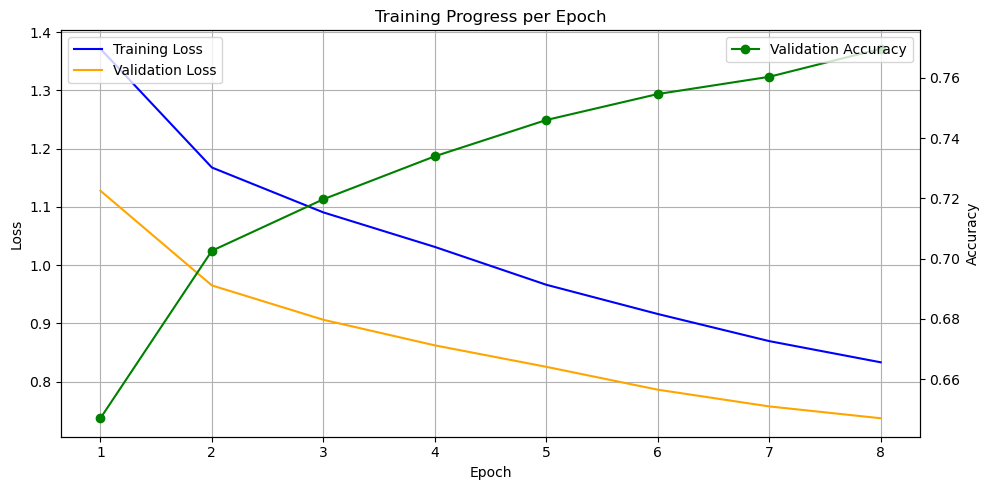

In [36]:
plot_metrics_by_epoch("./birdy-pool-class/checkpoint-25152/")

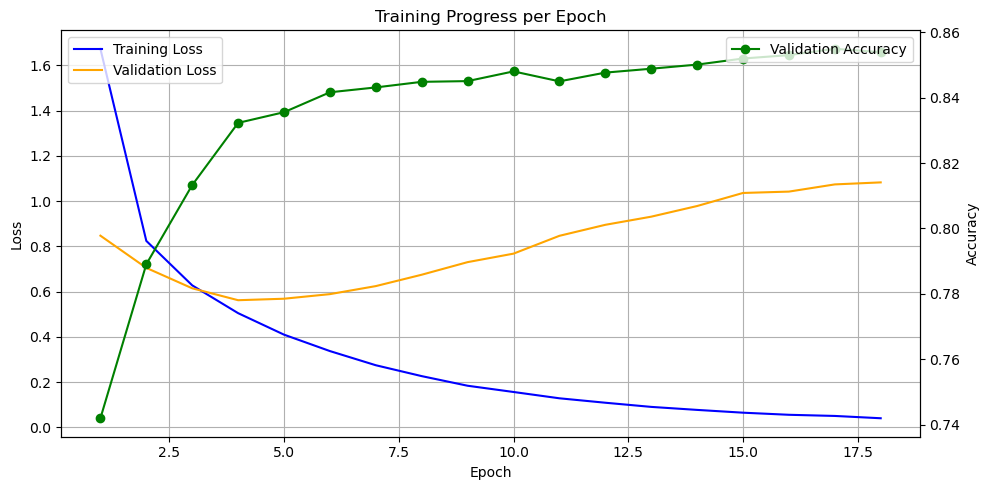

In [28]:
plot_metrics_by_epoch("./birdy-optimized/checkpoint-56592/")

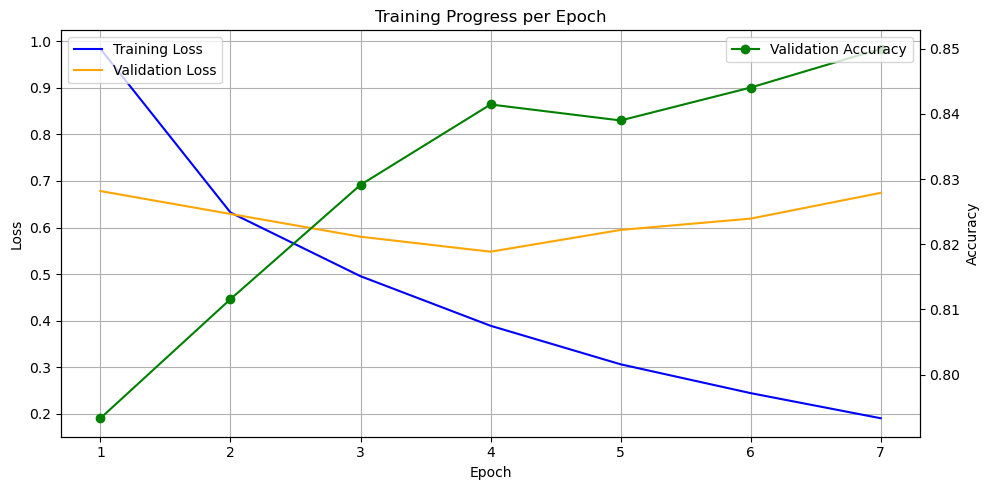

In [30]:
plot_metrics_by_epoch("./birdy-class-encoder/checkpoint-22008/")

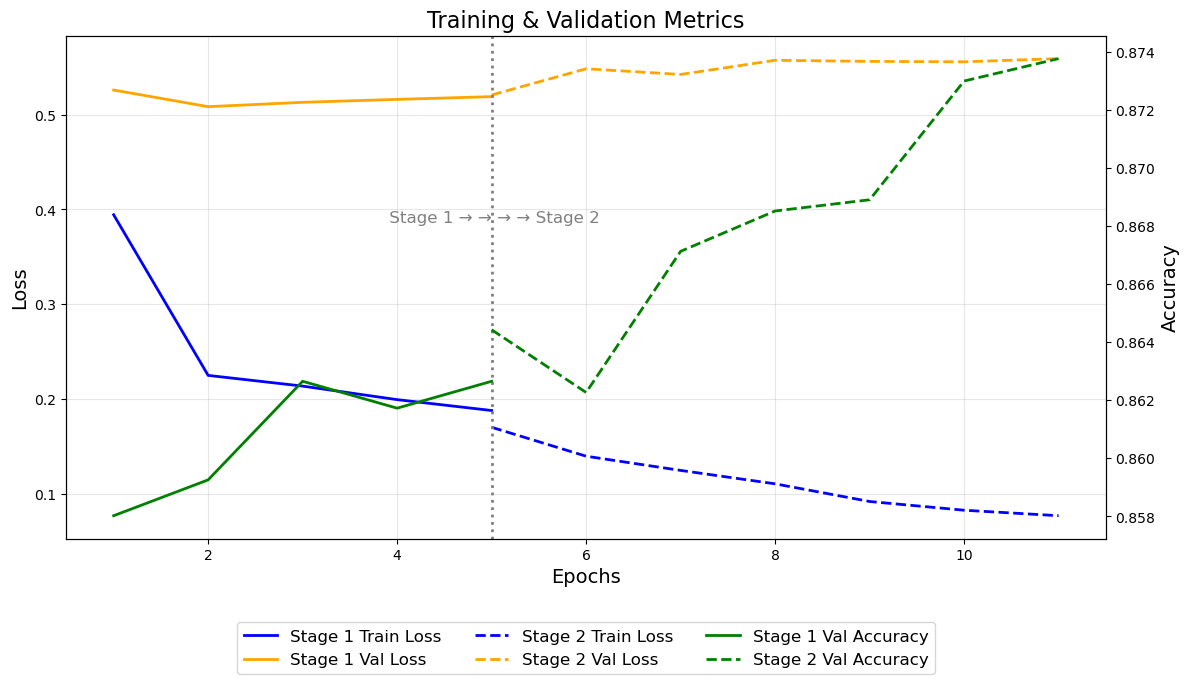

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_training_history_continuous_dual_axis(stage1_path="history_stage1.csv",
                                               stage2_path="history_stage2.csv"):
    """
    Loads Stage 1 and Stage 2 training histories and plots:
      - Train Loss (Stage 1 & Stage 2)
      - Validation Loss (Stage 1 & Stage 2)
      on LEFT axis,
      - Validation Accuracy (Stage 1 & Stage 2)
      on RIGHT axis.
      
    Stage 2 continues exactly from the last epoch of Stage 1 (no gap).
    """

    # Load CSVs
    df1 = pd.read_csv(stage1_path)
    df2 = pd.read_csv(stage2_path)

    # Epoch numbering
    epochs1 = range(1, len(df1) + 1)
    epochs2 = range(len(df1), len(df1) + len(df2))

    plt.figure(figsize=(12, 7))

    ax1 = plt.gca()  # left axis for losses

    # ------------------------------
    # Loss plots (LEFT AXIS)
    # ------------------------------
    ax1.plot(epochs1, df1["train_loss"], label="Stage 1 Train Loss", linewidth=2, color="blue")
    ax1.plot(epochs1, df1["val_loss"], label="Stage 1 Val Loss", linewidth=2, color="orange")

    ax1.plot(epochs2, df2["train_loss"], label="Stage 2 Train Loss", linestyle="--", linewidth=2, color="blue")
    ax1.plot(epochs2, df2["val_loss"], label="Stage 2 Val Loss", linestyle="--", linewidth=2, color="orange")

    ax1.set_xlabel("Epochs", fontsize=14)
    ax1.set_ylabel("Loss", fontsize=14)
    ax1.grid(True, alpha=0.3)

    # ------------------------------
    # Accuracy plots (RIGHT AXIS)
    # ------------------------------
    ax2 = ax1.twinx()
    ax2.plot(epochs1, df1["val_acc"], label="Stage 1 Val Accuracy",
             color="green", linewidth=2)
    ax2.plot(epochs2, df2["val_acc"], label="Stage 2 Val Accuracy",
             color="green", linestyle="--", linewidth=2)

    ax2.set_ylabel("Accuracy", fontsize=14)

    # ------------------------------
    # Combine legends
    # ------------------------------
    lines_left, labels_left = ax1.get_legend_handles_labels()
    lines_right, labels_right = ax2.get_legend_handles_labels()
    lines_left, labels_left = ax1.get_legend_handles_labels()
    lines_right, labels_right = ax2.get_legend_handles_labels()
    
    plt.legend(lines_left + lines_right,
               labels_left + labels_right,
               fontsize=12,
               loc="upper center",
               bbox_to_anchor=(0.5, -0.15),
               ncol=3)

    # Stage boundary line
    ax1.axvline(len(df1), color="gray", linestyle=":", linewidth=2)
    ax1.text(len(df1), ax1.get_ylim()[1] - 0.2, " Stage 1 → → → → Stage 2",
             rotation=0, va="bottom", ha="center", fontsize=12, color="gray")

    plt.title("Training & Validation Metrics", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_training_history_continuous_dual_axis(stage1_path="history_stage1.csv",
                                               stage2_path="history_stage2.csv")

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json

# ---------------------------------------------------------
# DISPLAY FUNCTION FROM YOU
# ---------------------------------------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": np.mean(preds == labels)}
    
def load_id2label(file_path="./id2label"):

    with open(file_path, "r", encoding="utf-8") as f:
        id2_label = json.load(f)
        return id2_label

def id2_label(id2_label, id):
    return id2_label[id]

def display_cm(labels, predicted_classes):

    id2_label = load_id2label()
    ticks = []
    for i in range(27):
        ticks.append(id2_label[str(i)])
    
    class_report = classification_report(labels, predicted_classes)
    print("Classification Report:\n", class_report)

    print("\nConfusion Matrix:")
    cm = confusion_matrix(labels, predicted_classes, normalize='true')

    cm_display = np.round(cm, 2)

    plt.figure(figsize=(20, 10))
    sns.heatmap(cm_display, annot=True, fmt='.2f', cmap='viridis', xticklabels=ticks, yticklabels=ticks)
    plt.title("Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

In [7]:
dataset = load_from_disk("./ds_cl")

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["text"],
                     padding="max_length",
                     truncation=True,
                     max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

Parameter 'function'=<function tokenize_function at 0x7f7b02faa700> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


  0%|          | 0/51 [00:00<?, ?ba/s]

  0%|          | 0/14 [00:00<?, ?ba/s]

  0%|          | 0/17 [00:00<?, ?ba/s]

Evaluation of:  test
{'accuracy': 0.7031762111912282}
Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.37      0.46       620
           1       0.74      0.48      0.58       499
           2       0.60      0.74      0.66       334
           3       0.91      0.72      0.81       166
           4       0.56      0.70      0.62       534
           5       0.90      0.71      0.79       791
           6       0.71      0.32      0.44       153
           7       0.45      0.61      0.52       964
           8       0.46      0.45      0.46       409
           9       0.77      0.81      0.79       994
          10       0.93      0.68      0.79       156
          11       0.64      0.60      0.62       491
          12       0.73      0.46      0.57       636
          13       0.69      0.69      0.69      1007
          14       0.82      0.86      0.84       841
          15       0.82      0.87      0.84       161
   

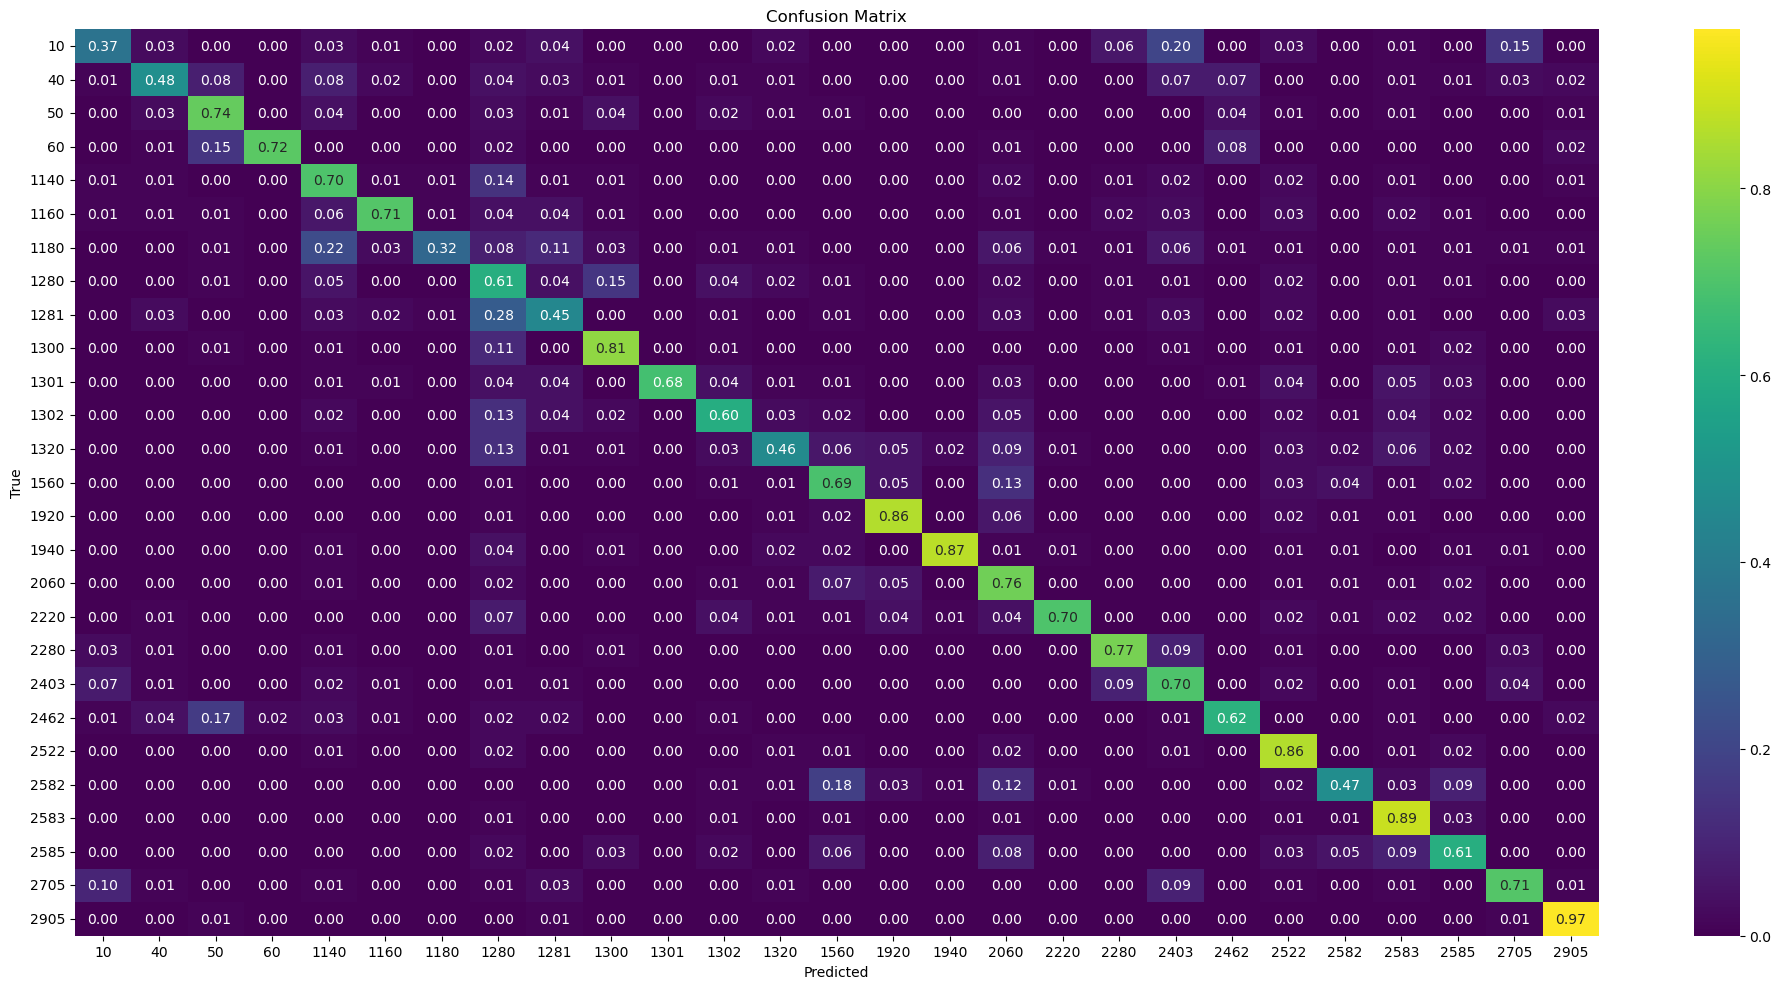

In [12]:
from datasets import load_from_disk
import numpy as np

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Path to your saved model folder
model_folder = "./birdy-pool-class/checkpoint-25152/"  # same as your TrainingArguments output_dir

model = BertForSequenceClassification.from_pretrained(model_folder)
trainer = Trainer(model=model)
labels, predicted_classes = get_predictions(trainer, tokenized_datasets, "test")
display_cm(labels, predicted_classes)

Evaluation of:  test
{'accuracy': 0.847088969668077}
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.61      0.61       620
           1       0.74      0.77      0.75       499
           2       0.83      0.84      0.83       334
           3       0.93      0.90      0.92       166
           4       0.76      0.83      0.79       534
           5       0.91      0.97      0.94       791
           6       0.83      0.57      0.67       153
           7       0.78      0.69      0.74       964
           8       0.69      0.60      0.65       409
           9       0.93      0.95      0.94       994
          10       0.94      0.85      0.89       156
          11       0.85      0.81      0.83       491
          12       0.76      0.84      0.80       636
          13       0.89      0.80      0.84      1007
          14       0.94      0.92      0.93       841
          15       0.86      0.93      0.90       161
    

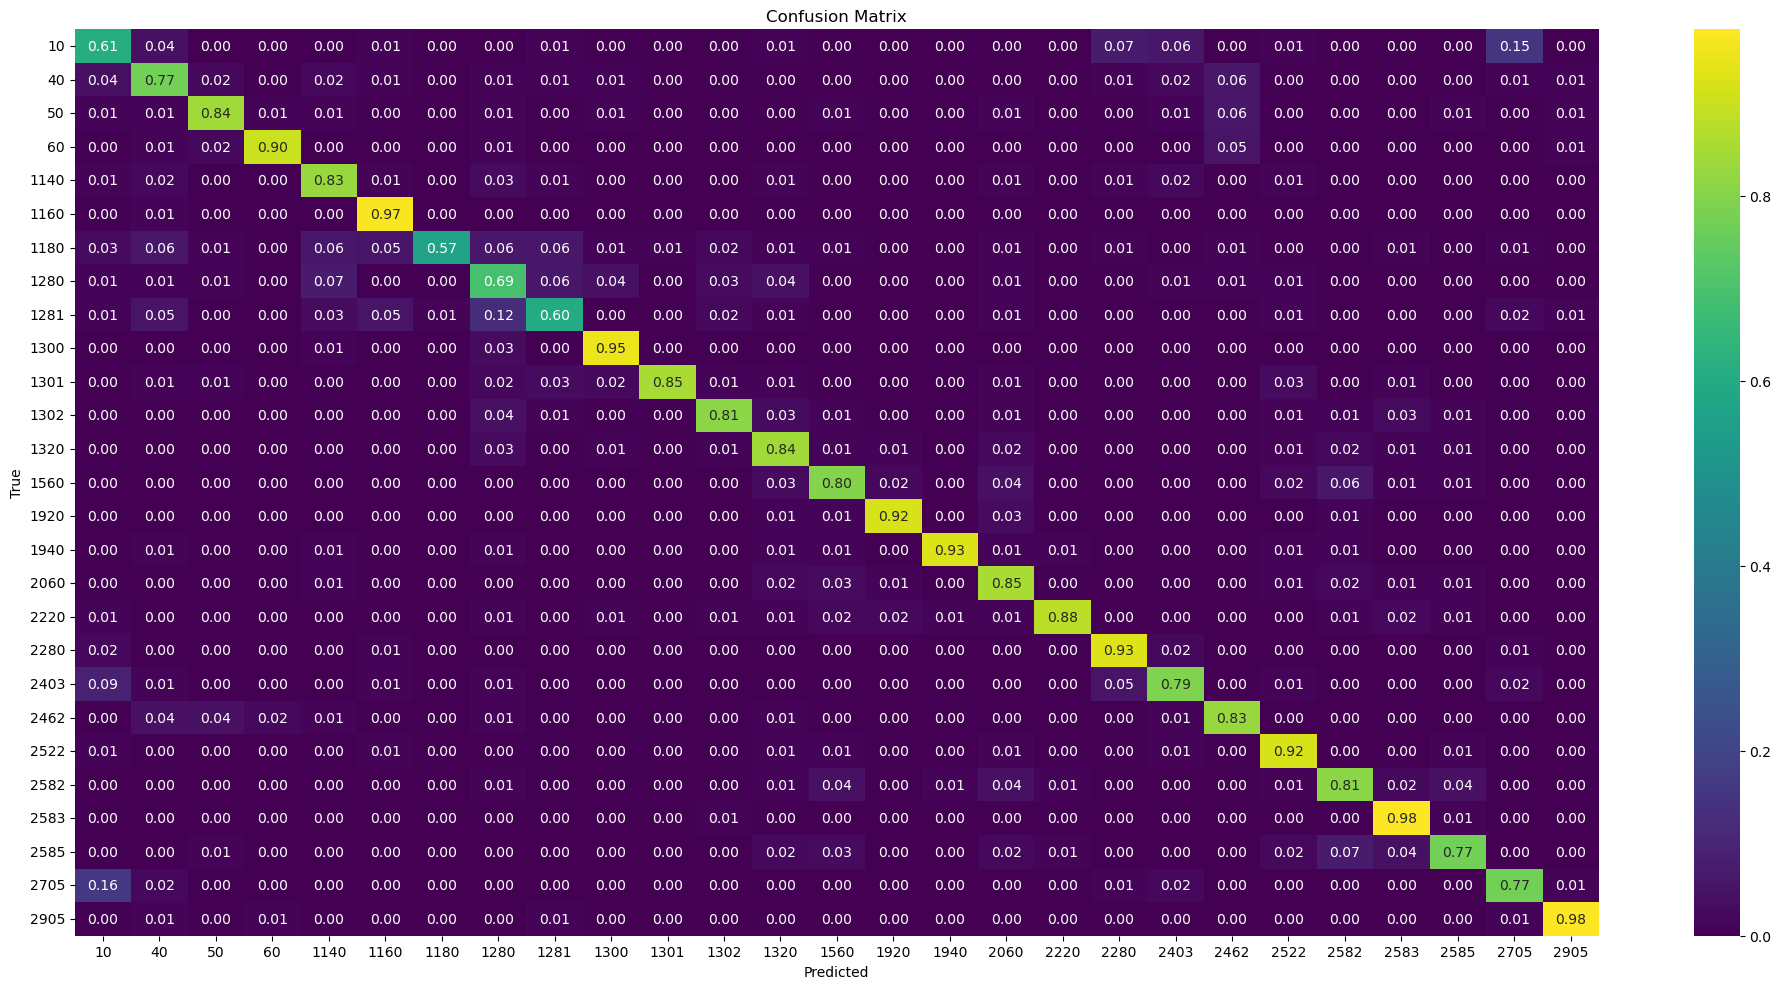

In [13]:
# Path to your saved model folder
model_folder = "./birdy-class-encoder/checkpoint-22008/"  # same as your TrainingArguments output_dir

model = BertForSequenceClassification.from_pretrained(model_folder)
trainer = Trainer(model=model)
labels, predicted_classes = get_predictions(trainer, tokenized_datasets, "test")
display_cm(labels, predicted_classes)

Evaluation of:  test
{'accuracy': 0.8511411715630773}
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.61      0.61       620
           1       0.76      0.76      0.76       499
           2       0.86      0.81      0.83       334
           3       0.93      0.92      0.93       166
           4       0.77      0.83      0.80       534
           5       0.93      0.96      0.95       791
           6       0.77      0.64      0.70       153
           7       0.75      0.71      0.73       964
           8       0.69      0.63      0.66       409
           9       0.93      0.94      0.94       994
          10       0.94      0.85      0.89       156
          11       0.83      0.82      0.82       491
          12       0.81      0.81      0.81       636
          13       0.87      0.84      0.85      1007
          14       0.92      0.94      0.93       841
          15       0.90      0.95      0.92       161
   

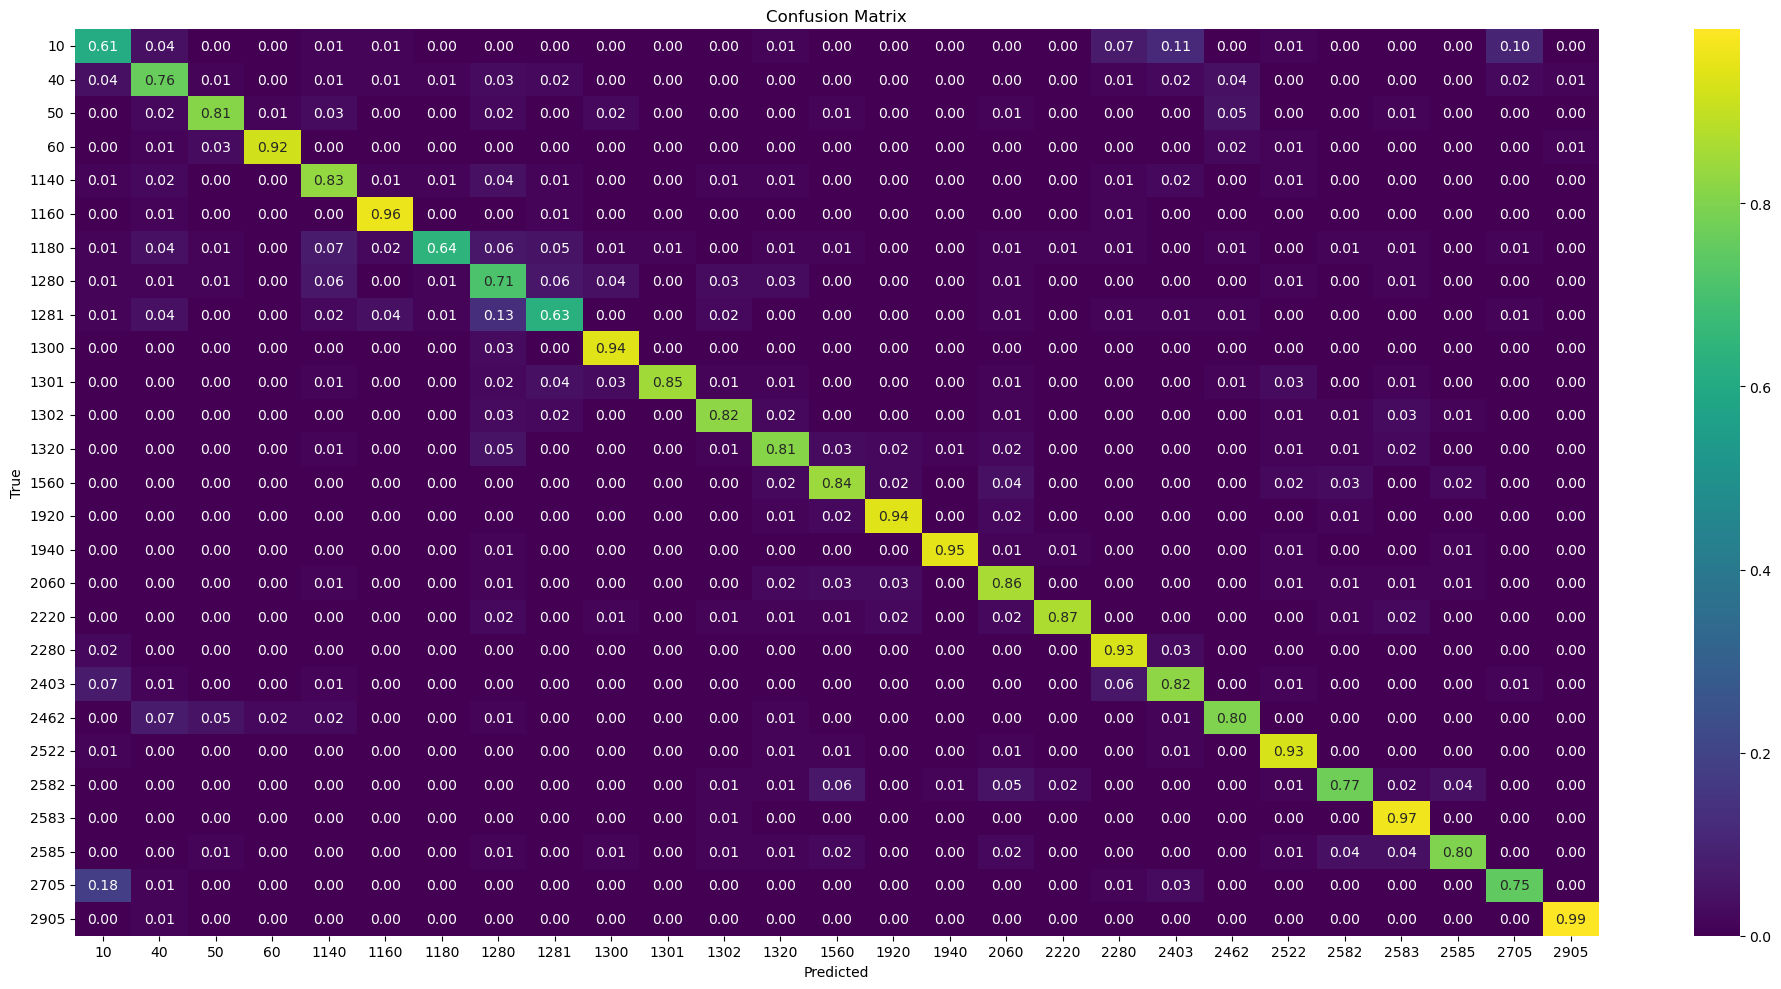

In [14]:
# Path to your saved model folder
model_folder = "./birdy-optimized/checkpoint-56592/"

model = BertForSequenceClassification.from_pretrained(model_folder)
trainer = Trainer(model=model)
labels, predicted_classes = get_predictions(trainer, tokenized_datasets, "test")
display_cm(labels, predicted_classes)